In [1]:
import matplotlib.pyplot as plt
import numpy as np
import time

from visualization.classifications import model_plot
#from visualization.point_clouds import vis_2pcs_aligned_vs_misaligned, vis_pc
from utils.optimize_parameters import optimize_with_ax
from utils.data_handling import read_nuscenes_data

In [ ]:
import ipywidgets as widgets
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

def plot_point_cloud_interactive(pc):
    def plot(elev=30, azim=30):
        fig = plt.figure()
        ax = fig.add_subplot(111, projection='3d')

        xs = pc[:, 0]
        ys = pc[:, 1]
        zs = pc[:, 2]

        ax.scatter(xs, ys, zs, marker='o')

        ax.set_xlabel('X Label')
        ax.set_ylabel('Y Label')
        ax.set_zlabel('Z Label')

        ax.view_init(elev, azim)
        plt.show()

    widgets.interact(plot, elev=(-90, 90, 5), azim=(-180, 180, 5))

PC_scenes = read_nuscenes_data()
PC_scene = PC_scenes[0]
PC_pair = PC_scene[0]

#plot_point_cloud_interactive(PC_pair.PC0.pc.cpu().numpy())


import plotly.graph_objs as go

def plot_point_cloud_plotly(pc):
    x, y, z = pc[:, 0], pc[:, 1], pc[:, 2]

    trace = go.Scatter3d(
        x=x, y=y, z=z,
        mode='markers',
        marker=dict(
            size=2,
            opacity=0.8
        )
    )

    layout = go.Layout(
        scene=dict(
            xaxis_title='X',
            yaxis_title='Y',
            zaxis_title='Z'
        )
    )

    fig = go.Figure(data=[trace], layout=layout)
    fig.show()

plot_point_cloud_plotly(PC_pair.PC0.pc.cpu().numpy())


In [ ]:

t1 = time.perf_counter()
# optimize_with_ax(samples_training=25, samples_test=25)
optimize_with_ax(samples_training=5, samples_test=5)

print(f"It took {round(time.perf_counter()-t1)} seconds to run basic run")
#model, X_train, X_test, y_train, y_test = main.differential_entropy_classification()

In [2]:
from utils.data_handling import read_nuscenes_data, gather_data
from classifiers.differential_entropy import differential_entropy_dataset
from classifiers.regression import perform_logistic_regression

PC_scenes = read_nuscenes_data(downsample_factor=4, n_scenes='all')
PC_scenes_training, PC_scenes_test = gather_data(PC_scenes, samples_training=40, samples_test=40)
del PC_scenes
scale_factor = 10
params = {
    "rmin": 0.2*scale_factor,
    "rmax": 1*scale_factor,
    "log_epsilon": -18.0,
    "alpha": 1.33*scale_factor,
    "E_reject": 0.20
}
X_train, y_train = differential_entropy_dataset(PC_scenes_training, params)
del PC_scenes_training
X_test, y_test = differential_entropy_dataset(PC_scenes_test, params)
del PC_scenes_test
model, accuracy_test = perform_logistic_regression(X_train, X_test, y_train, y_test, verbose=True)
print(f"Accuracy: {accuracy_test} with parameters\n {params}")
print("Finito!")


Loading NuScenes tables for version v1.0-mini...
23 category,
8 attribute,
4 visibility,
911 instance,
12 sensor,
120 calibrated_sensor,
31206 ego_pose,
8 log,
10 scene,
404 sample,
31206 sample_data,
18538 sample_annotation,
4 map,
Done loading in 0.546 seconds.
Reverse indexing ...
Done reverse indexing in 0.1 seconds.
We have collected 1 scenes
We have collected 2 scenes
We have collected 3 scenes
We have collected 4 scenes
We have collected 5 scenes
We have collected 2000 number of samples
We have collected 6 scenes
We have collected 7 scenes
We have collected 8 scenes
We have collected 9 scenes
We have collected 10 scenes
We have collected all data from the dataset
Total number of samples: 3925
Total number of scenes:  10

Overlap share: 1.0 (eval time: 1.0275 sec)
[joint|sep|metric|misaligned]: [2.744|2.648|0.096|False]
Mean abs metric aligned    0.0962 (N = 1)
Execution time: 1.878 sec

Overlap share: 1.0 (eval time: 0.0136 sec)
[joint|sep|metric|misaligned]: [2.398|2.287|0.11|F

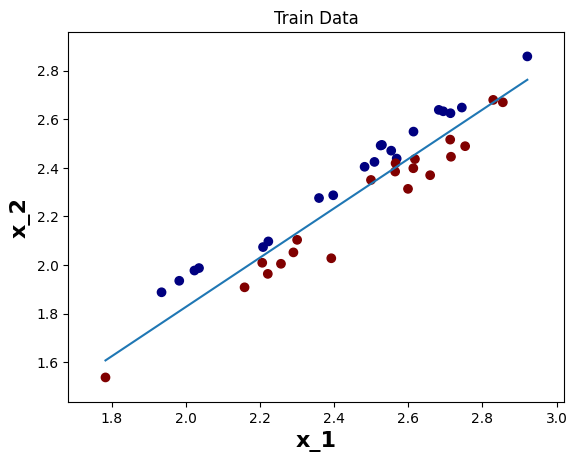

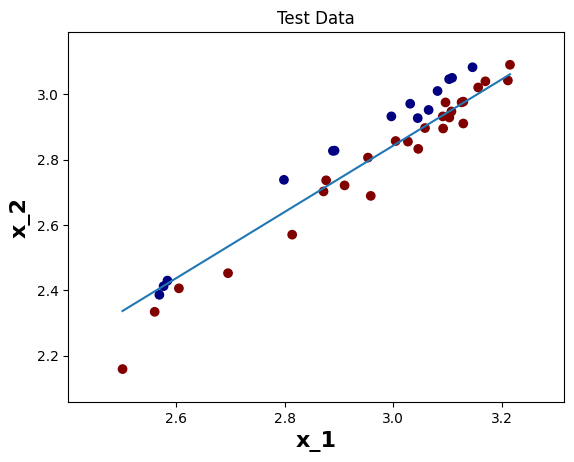

In [3]:
# Train Data
model_plot(model,X_train,y_train,'Train Data')
# Test Dataset Results
model_plot(model,X_test,y_test,'Test Data')